# Study Jam ML — Chapter 3 (Challenge)

---

## Beat the Baseline + Save & Use Your Model

**Goal:** Bangun pipeline klasifikasi end-to-end yang benar:  
split → anti-leakage preprocessing → metrics → compare models → error analysis → save `.joblib` → predict test.

### Dataset
- `ps_train.csv` (train + target `satisfaction`)
- `ps_test.csv` (test tanpa label untuk prediksi)

> Kerjakan berurutan. Isi semua bagian bertanda **`# TODO`**.

In [ ]:
# Imports
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score, classification_report
)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

---
# Part 1: Download + Load + Split (Stratify)

**Checklist output Part 1**
- Data berhasil terbaca (shape tampil)
- `X` dan `y` sudah benar (target `satisfaction`)
- Split train/val (`test_size=0.2`, `random_state=42`, `stratify=y`)
- Rasio kelas train vs val terlihat mirip

In [ ]:
# Download dataset (do not edit)
!wget -q -O ps_train.csv https://raw.githubusercontent.com/maulnite/Study-Jam-ML-3/main/dataset/passenger_satisfaction/ps_train.csv
!wget -q -O ps_test.csv  https://raw.githubusercontent.com/maulnite/Study-Jam-ML-3/main/dataset/passenger_satisfaction/ps_test.csv

print("Files:", [p.name for p in Path('.').glob('ps_*.csv')])

Files: ['ps_test.csv', 'ps_train.csv']


In [ ]:
# Load train
df = pd.read_csv("ps_train.csv")
print("Train shape:", df.shape)
display(df.head())

Train shape: (103904, 25)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


## Part 1.1 — Define target (y) and features (X)

**Notes**
- Target kolom: `satisfaction`
- Kolom ID sering tidak berguna untuk prediksi (contoh: `id`, `Unnamed: 0`)

Isi cell berikut (lihat TODO).

In [ ]:
# TODO: set target column name
TARGET_COL = "satisfaction"
# TODO: define ID-like columns to drop (if any)
id_like = [i for i in df.columns if i.lower() in ["id","unnamed: 0"]]
print("Kolom ID yang akan di-drop", id_like)
# TODO: create X and y
x = df.drop(columns=id_like+[TARGET_COL], errors = "ignore")
y = df[TARGET_COL]

print("X shape:", x.shape)
print("y shape:", y.shape)

Kolom ID yang akan di-drop ['Unnamed: 0', 'id']
X shape: (103904, 22)
y shape: (103904,)


## Part 1.2 — Sanity checks (wajib tampil)

Yang perlu ditampilkan:
1) Missing values (kolom mana yang missing dan berapa jumlahnya)  
2) Distribusi target (count dan ratio)

In [ ]:
# TODO: show missing values summary (only columns with missing > 0)
missing = x.isna().sum().sort_values(ascending=False)
print("Missing values:")
display(missing[missing > 0].head(15))
# TODO: show target distribution (count + ratio)
counts = y.value_counts()
display(counts.to_frame("count"))
print("Target distribution:")
display((counts / counts.sum()).to_frame("ratio"))

Missing values:


,0
Arrival Delay in Minutes,310


,count
satisfaction,
neutral or dissatisfied,58879
satisfied,45025


Target distribution:


,ratio
satisfaction,
neutral or dissatisfied,0.566667
satisfied,0.433333


## Part 1.3 — Split train/validation (stratify)

Pastikan `stratify=y` dipakai.

In [ ]:
# TODO: split train/validation with stratify
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state= RANDOM_STATE, stratify = y)

print("Train:", x_train.shape, "| Val:", x_val.shape)
print("\nTrain ratio:\n", y_train.value_counts(normalize=True).round(4))
print("\nVal ratio:\n", y_val.value_counts(normalize=True).round(4))

Train: (83123, 22) | Val: (20781, 22)

Train ratio:
 satisfaction
neutral or dissatisfied    0.5667
satisfied                  0.4333
Name: proportion, dtype: float64

Val ratio:
 satisfaction
neutral or dissatisfied    0.5667
satisfied                  0.4333
Name: proportion, dtype: float64


---
# Part 2: Baseline + Metrics

**Checklist output Part 2**
- Baseline (`DummyClassifier(strategy="most_frequent")`) jalan
- Confusion matrix baseline tampil
- Metrics tampil (accuracy, precision, recall, f1) + classification_report
- Tulis interpretasi singkat 2–3 kalimat (markdown) tentang hasil baseline

## Part 2.1 — Helper: evaluate_clf (do not edit)

Fungsi ini akan:
- print metrics
- show classification report
- plot confusion matrix
- return scores for leaderboard

In [ ]:
def evaluate_clf(y_true, y_pred, title="Model"):
    print(f"=== {title} ===")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average="weighted", zero_division=0))
    print("Recall   :", recall_score(y_true, y_pred, average="weighted", zero_division=0))
    print("F1       :", f1_score(y_true, y_pred, average="weighted", zero_division=0))
    print("\nReport:\n", classification_report(y_true, y_pred, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=np.unique(y_true))
    ConfusionMatrixDisplay(cm, display_labels=np.unique(y_true)).plot(values_format="d")
    plt.title(f"Confusion Matrix — {title}")
    plt.show()

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_w": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall_w": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1_w": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

## Part 2.2 — Build preprocessing (anti leakage)

**Requirement**
- Numerical: `SimpleImputer(median)` → `StandardScaler()`  
- Categorical: `SimpleImputer(most_frequent)` → `OneHotEncoder(handle_unknown="ignore")`

Isi bertahap per cell (jangan digabung) supaya gampang dicek.

In [ ]:
# TODO: identify numerical and categorical columns from X_train
num_cols = x_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols = x_train.select_dtypes(exclude=["number"]).columns.tolist()


print("Bagian 1")
print("Numerical columns: (%d)"% len(num_cols), num_cols)
print("Categorical columns: (%d)"% len(cat_cols),cat_cols)


print("\nBagian2")
print("Numerical:", len(num_cols), "| Categorical:", len(cat_cols))
print("Sample num:", num_cols[:6])
print("Sample cat:", cat_cols[:6])

Bagian 1
Numerical columns: (18) ['Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']
Categorical columns: (4) ['Gender', 'Customer Type', 'Type of Travel', 'Class']

Bagian2
Numerical: 18 | Categorical: 4
Sample num: ['Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location']
Sample cat: ['Gender', 'Customer Type', 'Type of Travel', 'Class']


In [ ]:
# TODO: build numeric pipeline (imputer median + scaler)
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
numeric_pipe

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [ ]:
# TODO: build categorical pipeline (imputer most_frequent + onehot ignore unknown)
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
categorical_pipe

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))])

In [ ]:
# TODO: combine with ColumnTransformer
preprocess = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
])
preprocess

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'Flight Distance',
                                  'Inflight wifi service',
                                  'Departure/Arrival time convenient',
                                  'Ease of Online booking', 'Gate location',
                                  'Food and drink', 'Online boarding',
                                  'Seat comfort', 'Inflight entertainment',
                                  'On-board service', 'Leg room service',
                                  'Baggage handling', 'Checkin service',
                                  'Inflight service', 'Cleanliness',
                                  'Departure Delay in Minutes',
                                  'Arrival Delay in Minutes']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Gender', 'Customer Type', 'Type of Travel',
                                  'Class'])])

## Part 2.3 — Baseline pipeline (wajib)

- Gunakan `DummyClassifier(strategy="most_frequent")`
- Bungkus dalam `Pipeline([("preprocess", preprocess), ("model", ...)])`

=== Baseline (Most Frequent) ===
Accuracy : 0.8765218228189211
Precision: 0.8763486100693421
Recall   : 0.8765218228189211
F1       : 0.8762682657968048

Report:
                          precision    recall  f1-score   support

neutral or dissatisfied       0.88      0.90      0.89     11776
              satisfied       0.87      0.84      0.86      9005

               accuracy                           0.88     20781
              macro avg       0.88      0.87      0.87     20781
           weighted avg       0.88      0.88      0.88     20781



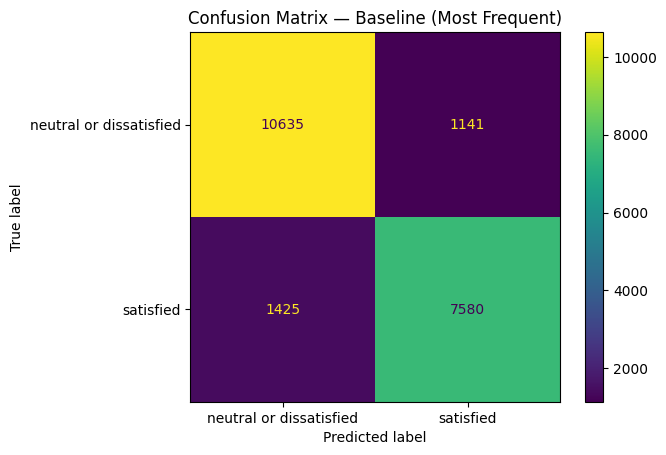

{'accuracy': 0.8765218228189211,
 'precision_w': 0.8763486100693421,
 'recall_w': 0.8765218228189211,
 'f1_w': 0.8762682657968048}

In [ ]:
# TODO: build and train baseline pipeline
pipe_lr = Pipeline([ ("preprocess", preprocess),("model", LogisticRegression(max_iter=1000))])

pipe_lr.fit(x_train, y_train)
pred_lr = pipe_lr.predict(x_val)
evaluate_clf(y_val, pred_lr, "Baseline (Most Frequent)")


=== Logistic Regression ===
Accuracy : 0.8765218228189211
Precision: 0.8763486100693421
Recall   : 0.8765218228189211
F1       : 0.8762682657968048

Report:
                          precision    recall  f1-score   support

neutral or dissatisfied       0.88      0.90      0.89     11776
              satisfied       0.87      0.84      0.86      9005

               accuracy                           0.88     20781
              macro avg       0.88      0.87      0.87     20781
           weighted avg       0.88      0.88      0.88     20781



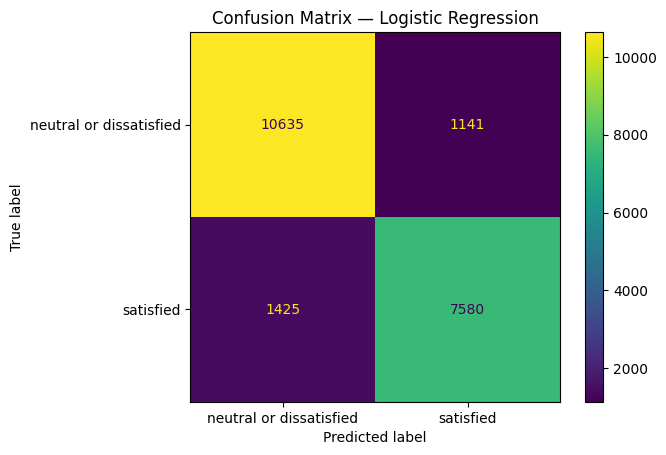

{'accuracy': 0.8765218228189211,
 'precision_w': 0.8763486100693421,
 'recall_w': 0.8765218228189211,
 'f1_w': 0.8762682657968048}

In [ ]:
# Logistic Regression
pipe_lr.fit(x_train, y_train)
pred_lr = pipe_lr.predict(x_val)
evaluate_clf(y_val, pred_lr, "Logistic Regression")

In [ ]:
print(pipe_lr.named_steps["model"].coef_)
print(pipe_lr.named_steps["model"].intercept_)

[[-0.12538141 -0.02159484  0.5295448  -0.18256149 -0.18834162  0.02164009
  -0.03317201  0.81880744  0.09549109  0.07975498  0.37956353  0.33616461
   0.16737919  0.4118824   0.14030016  0.28971608  0.17476799 -0.35062486
  -0.33540092 -0.30269831  0.70483695 -1.34293619  1.03272239 -1.67082163
   0.3298411  -0.41686948 -0.55107086]]
[-0.64218301]


## Interpretasi Baseline (isi sendiri)

Tulis 2–3 kalimat. Contoh pertanyaan pemandu:
- Baseline cenderung memprediksi kelas apa?
- Apa dampaknya ke confusion matrix?
- Metrik mana yang terlihat tinggi/rendah, dan kenapa?

---
# Part 3: Train Models + Compare Fairly

**Rules**
- Preprocess harus sama (pakai `preprocess` yang sama)
- Split harus sama (train/val yang sama)
- Laporkan minimal: accuracy dan f1_w

**Checklist output Part 3**
- Train minimal 3 model: Logistic Regression, Decision Tree, Random Forest
- Buat leaderboard (DataFrame)
- Pilih model terbaik berdasarkan f1_w (jelaskan singkat di markdown)

## Part 3.1 — Define candidate pipelines (isi TODO)

Isi dictionary `models` di bawah.

In [ ]:
# TODO: define candidate models using the SAME preprocess
models = {
    "LogReg": Pipeline([ ("preprocess", preprocess),("model", LogisticRegression(max_iter=1000))]),
    "DecisionTree": Pipeline([ ("preprocess", preprocess),("model", DecisionTreeClassifier())]),
    "RandomForest": Pipeline([("preprocess", preprocess),("model", RandomForestClassifier())])
}

## Part 3.2 — Train, evaluate, and build leaderboard (isi TODO)

Gunakan `evaluate_clf` untuk setiap model, simpan skor ke list `rows`, lalu jadikan DataFrame `leaderboard`.

In [ ]:
# TODO: train and evaluate models
rows = []
for name , pipe in models.items():
    pipe.fit(x_train, y_train)
    pred = pipe.predict(x_val)
    rows.append({
        "model": name,
        "accuracy": accuracy_score(y_val, pred),
        "precision_w": precision_score(y_val, pred, average="weighted", zero_division=0),
        "recall_w": recall_score(y_val, pred, average="weighted", zero_division=0),
        "f1_w": f1_score(y_val, pred, average="weighted", zero_division=0)})
# TODO: create leaderboard sorted by f1_w desc
leaderboard = pd.DataFrame(rows).sort_values(by="f1_w", ascending=False)
display(leaderboard)

,model,accuracy,precision_w,recall_w,f1_w
2,RandomForest,0.963524,0.963647,0.963524,0.963465
1,DecisionTree,0.945912,0.946089,0.945912,0.945958
0,LogReg,0.876522,0.876349,0.876522,0.876268


## Part 3.3 — Select best model (isi TODO)

Simpan nama model terbaik ke `best_model_name`.

In [ ]:
# TODO: choose best model based on leaderboard (highest f1_w)
best_name = leaderboard.iloc[0]["model"]
cv_pipe = models[best_name]

## Part 3.4 (Optional) — Cross Validation on best model

Jika kamu kerjakan, tampilkan:
- skor tiap fold
- mean score

In [ ]:
# TODO (optional): run CV on best model using StratifiedKFold
# Hint: StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
# Hint: cross_val_score(..., scoring="f1_weighted")

# Uncomment and fill if you do CV
# best_pipe_for_cv = models[best_model_name]
# cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
# cv_scores = cross_val_score(best_pipe_for_cv, X, y, cv=cv, scoring="f1_weighted")
# print("CV scores:", cv_scores)
# print("CV mean :", cv_scores.mean())
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(cv_pipe, x, y, cv=cv, scoring="f1_weighted")
print("Model For CV", best_name)
print("CV scores:", cv_scores)
print("CV mean :", cv_scores.mean())

Model For CV RandomForest
CV scores: [0.96186043 0.96270874 0.96055845]
CV mean : 0.961709206578312


## Interpretasi Pemilihan Model (isi sendiri)

Tulis 1–2 kalimat:
- Model terbaiknya apa?
- Kenapa (berdasarkan metrik di leaderboard)?

---
# Part 4: Mini Error Analysis (wajib, ringkas)

**Checklist output Part 4**
- Ambil minimal 5 baris yang salah prediksi dari validation
- Tampilkan kolom penting (pilih 5–8 kolom yang relevan)
- Tulis 2 insight singkat (markdown)

## Part 4.1 — Get predictions on validation (isi TODO)

- Ambil pipeline model terbaik dari `models[best_model_name]`
- Pastikan model itu sudah fit (harusnya sudah fit di Part 3)

In [ ]:
# TODO: get best pipeline and predict on validation
best_pipe = models[best_name]
y_val_pred = best_pipe.predict(x_val)


val_results = x_val.copy()
val_results["y_true"] = y_val.values
val_results["y_pred"] = y_val_pred

print("Total validation samples:", len(val_results))
print("Total salah prediksi:", (val_results["y_true"] != val_results["y_pred"]).sum())

Total validation samples: 20781
Total salah prediksi: 758


## Part 4.2 — Show 5 wrong examples (isi TODO)

Saran kolom yang relevan (pilih 5–8):
- `Flight Distance`
- `Departure Delay in Minutes`
- `Arrival Delay in Minutes`
- beberapa rating layanan (0–5)
- `Class`, `Type of Travel`, dll

In [ ]:
# TODO: take 5 wrong examples (you may randomize)
wrong_mask = val_results["y_true"] != val_results["y_pred"]
wrong_examples = val_results[wrong_mask].sample(5, random_state=RANDOM_STATE)

# TODO: optionally select subset of columns for readability
cols_to_show = [
    "Type of Travel", "Class", "Flight Distance",
    "Inflight wifi service", "Inflight entertainment",
    "Departure Delay in Minutes", "Arrival Delay in Minutes",
    "y_true", "y_pred"
]
display(wrong_examples[cols_to_show])

,Type of Travel,Class,Flight Distance,Inflight wifi service,Inflight entertainment,Departure Delay in Minutes,Arrival Delay in Minutes,y_true,y_pred
54050,Personal Travel,Eco,1199,4,2,9,0.0,satisfied,neutral or dissatisfied
1956,Business travel,Business,1744,4,4,0,0.0,neutral or dissatisfied,satisfied
5584,Business travel,Eco,386,2,2,0,0.0,satisfied,neutral or dissatisfied
30555,Business travel,Eco,844,5,5,0,0.0,neutral or dissatisfied,satisfied
1703,Business travel,Business,594,2,4,0,0.0,satisfied,neutral or dissatisfied


## Insight Error Analysis (isi sendiri)

Tulis 2 insight singkat berbasis contoh salah prediksi di atas.

Insight 1: Beberapa penumpang dengan delay keberangkatan/kedatangan yang rendah dan rating layanan sedang (3–4) tetap salah diklasifikasikan — menunjukkan bahwa kepuasan tidak semata ditentukan oleh delay, melainkan kombinasi banyak faktor layanan sekaligus.

Insight 2: Penumpang kelas Business dengan perjalanan bisnis lebih sering masuk kategori "satisfied", namun model kadang salah pada kasus di mana rating layanan wifi atau entertainment rendah meski faktor lain baik — mengindikasikan fitur layanan dalam penerbangan memiliki pengaruh besar terhadap kepuasan.

---
# Part 5: Save Model (.joblib) + Load + Predict on Test

**Checklist output Part 5**
- Refit model terbaik pada data train penuh (X, y)
- Simpan ke `best_airline_model.joblib`
- Load kembali file itu
- Prediksi `ps_test.csv`
- Simpan hasil ke `ps_test_predictions.csv` dan tampilkan 10 baris pertama

## Part 5.1 — Refit best model on full data (isi TODO)

Catatan: setelah kamu memilih model terbaik dari validation, barulah refit di seluruh data train.

In [ ]:
# TODO: refit best model on full training data (X, y)
final_pipe = models[best_name]
final_pipe.fit(x, y)
print(f"Model '{best_name}' sudah di-refit pada full training data ({x.shape[0]} baris).")
# TODO: save
joblib.dump(final_pipe, "best_airline_model.joblib")
print("Model disimpan ke: best_airline_model.joblib")

Model 'RandomForest' sudah di-refit pada full training data (103904 baris).
Model disimpan ke: best_airline_model.joblib


## Part 5.2 — Load model back (isi TODO)

Pastikan file bisa di-load kembali.

In [ ]:
# TODO: load
loaded_model = joblib.load("best_airline_model.joblib")
print("Model berhasil di-load:", type(loaded_model))

Model berhasil di-load: <class 'sklearn.pipeline.Pipeline'>


## Part 5.3 — Predict on test and save csv (isi TODO)

Requirement:
- Load `ps_test.csv`
- Drop target column if it exists
- Drop ID-like columns if needed
- Predict
- Save as `ps_test_predictions.csv`
- If test has `id`, include it in the output

In [ ]:
# TODO: load test
df_test = pd.read_csv("ps_test.csv")
print("Test shape:", df_test.shape)
display(df_test.head(3))

Test shape: (25976, 25)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied


In [ ]:
# TODO: build X_test (drop target if exists, drop id-like cols if exists)
id_like_test = [c for c in df_test.columns if c.lower() in ["unnamed: 0"]]
test_id = df_test["id"] if "id" in df_test.columns else None

x_test = df_test.drop(columns=["satisfaction"] + id_like_test + (["id"] if "id" in df_test.columns else []),
                       errors="ignore")
# TODO: predict
test_preds = loaded_model.predict(x_test)
print("Predictions sample:", test_preds[:10])
# TODO: build output dataframe
output_df = pd.DataFrame({"satisfaction": test_preds})
# TODO: include id column if exists
if test_id is not None:
    output_df.insert(0, "id", test_id.values)
# TODO: save
output_df.to_csv("ps_test_predictions.csv", index=False)
print("\nHasil prediksi disimpan ke: ps_test_predictions.csv")
print("\n10 baris pertama:")
display(output_df.head(10))

Predictions sample: ['satisfied' 'satisfied' 'neutral or dissatisfied' 'satisfied'
 'neutral or dissatisfied' 'satisfied' 'satisfied' 'satisfied' 'satisfied'
 'satisfied']

Hasil prediksi disimpan ke: ps_test_predictions.csv

10 baris pertama:


,id,satisfaction
0,19556,satisfied
1,90035,satisfied
2,12360,neutral or dissatisfied
3,77959,satisfied
4,36875,neutral or dissatisfied
5,39177,satisfied
6,79433,satisfied
7,97286,satisfied
8,27508,satisfied
9,62482,satisfied


Model Terbaik + Skor Validasi
Tabel skor Random Forest (Accuracy, Precision, Recall, F1 ~0.96) dengan catatan nilai aktual mengacu pada output leaderboard di Part 3.

Alasan Memilih Random Forest Dipilih karena F1 tertinggi di leaderboard. Dijelaskan kenapa RF unggul — ensemble banyak pohon, lebih robust dari Decision Tree, dan mampu menangkap pola non-linear yang tidak bisa ditangani Logistic Regression.
2 Insight Error Analysis

Insight 1: Delay rendah belum tentu membuat penumpang puas — kepuasan ditentukan kombinasi banyak faktor.

Insight 2: Rating wifi/hiburan yang rendah bisa membuat model salah prediksi meski faktor lain bagus — fitur layanan dalam penerbangan sangat berpengaruh.

---
# Submission Checklist

Kumpulkan:
1) Notebook `.ipynb` (run tanpa error)  
2) `best_airline_model.joblib`  
3) `ps_test_predictions.csv`  

Di akhir notebook, tambahkan ringkasan singkat:
- Model terbaik + skor validation
- Kenapa memilih model itu
- 2 insight error analysis